Task Description: Fe Deficiency detection based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm).
#### <font color=red> Delete 18 spectra from the beginning and 17 from the end of all Train and Test sets --> 169 (from X449.35 up to X951.17) are left in the case of not reducing the size of dataset more </font>
#### Train size = Original dataset (144, 169)
#### Test size = Merge Anna 1, Anna 2, and Marco1 (86, 169) 
#### <font color=red> The SHAP plots are for class [1] which is "Fe deficiency" here </font>

#### Methods
- Logistic Regression (Linear)
- Random Forest

In [15]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()


#### Load and Preprocess
- Drop the 'Leaf' column as it provides no classification information (it has the same value 'YL' for all rows)
- Encode the 'Thesis' column (the ground-truth label)
- Separate the dataset into features and labels
- check class imbalance 1) in the whole dataset 2) per each plant
- Check for missing values in the entire DataFrame (There was none)
- Feature selection - Get feature importances using Random Forest
- Scale the feature values (Columns here)
##### <font color=red> Watch the reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions) for execution </font>
##### <font color=red> Watch the consistency between encoded labels of the original dataset and the new one for execution </font>

    X702.58   X705.57   X714.55   X708.57   X711.56   X542.68   X533.89  \
0  0.156458  0.193107  0.297853  0.229255  0.264542  0.163627  0.151072   
1  0.157914  0.193956  0.296471  0.229751  0.263767  0.163798  0.151730   
2  0.143176  0.178240  0.281965  0.213600  0.248548  0.144303  0.132345   
3  0.142578  0.176441  0.275202  0.210461  0.243357  0.145374  0.134373   
4  0.161199  0.196912  0.294480  0.231312  0.264176  0.164652  0.152839   

    X563.24   X530.96  
0  0.158688  0.142530  
1  0.158534  0.143493  
2  0.140744  0.124589  
3  0.140789  0.127064  
4  0.160037  0.144763  
Encoded Class Distribution:
0    108
1     72
Name: count, dtype: int64


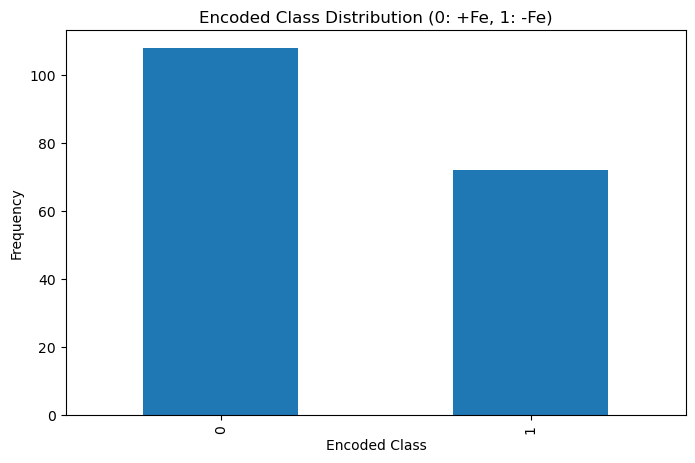

Columns with missing values: []

Number of features with 0.0 importance: 0


(180, 9)

In [81]:
# new
# Step 1: Load the dataset
# data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# when I added 36 samples manually, choosing first 9 samples of each plant from Michele_test.txt to Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_modified.txt', delimiter='\t')
# add 36 samples to the train set randomly, does not work properly now
# data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_modified1.txt', delimiter='\t')
# Step 2: Preprocess the data
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])
# Separate the dataset into features and labels
# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X = data.iloc[:, 3:]  # Features
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths/Trimmed
# X = data.iloc[:, 21:190]

#### SHAP FEATURES EXTRACTED WHEN ALL WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, Logistic Regression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X985.05', 'X997.40', 'X720.54', 'X994.31', 'X708.57', 'X723.53']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X708.57', 'X720.54', 'X705.57', 'X723.53', 'X702.58', 'X750.54', 'X726.53']
# For Merged Dataset, All Features, Random Forest
# desired_columns = ['X705.57', 'X702.58', 'X708.57', 'X711.56', 'X714.55', 'X569.12', 'X542.68', 'X699.60', 'X560.30']
# For Merged Dataset, Some Features, Random Forest
# desired_columns = ['X714.55', 'X702.58', 'X711.56', 'X708.57', 'X705.57', 'X566.18', 'X699.60', 'X589.75', 'X580.90']

#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X720.54', 'X708.57', 'X723.53', 'X726.53', 'X729.53', 'X819.95']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X753.55', 'X717.54', 'X756.56', 'X711.56', 'X708.57', 'X705.57', 'X720.54', 'X807.84']
# For Merged Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X563.24', 'X542.68', 'X720.54']
# For Merged Dataset, Some Features, Random Forest
#desired_columns = ['X711.56', 'X717.54', 'X708.57', 'X539.75', 'X545.62', 'X702.58', 'X648.95', 'X554.43','X563.24']


### Trimmed, New index that was attained using a new train set ###
### All Features, LogisticRegression
# desired_columns = ['X948.10', 'X941.95', 'X945.02', 'X951.17', 'X723.53', 'X938.88', 'X926.61', 'X717.54', 'X726.53']
### All Features, Random Forest
desired_columns = ['X702.58', 'X705.57', 'X714.55', 'X708.57', 'X711.56', 'X542.68', 'X533.89', 'X563.24', 'X530.96']


#### Ablation Test ###
# For Merged Dataset, All Features, LogisticRegression&Random, Use Top 3 ---> Index1
# desired_columns = ['X714.55', 'X717.54', 'X711.56'] 
# For Merged Dataset, All Features, RandomForest, Use Top 3 ---> Index2
# desired_columns = ['X702.58', 'X714.55', 'X705.57'] 
# For Merged Dataset, All Features, Logistic & RandomForest, Use Common top 4 --->Index3
# desired_columns = ['X708.57', 'X711.56', 'X714.55', 'X717.54'] 

### Test single features in Index 1 above ###
# For Merged Dataset, All Features, 
# desired_columns = ['X702.58'] 
# desired_columns = ['X714.55'] 
# desired_columns = ['X705.57'] 

X = data[desired_columns]
print(X.head())
# y = data['Thesis']
# # Encode the 'Thesis' column
# # le = LabelEncoder()
# # y = le.fit_transform(y)
# # Encode 'Thesis' column based on "+Fe" and "-Fe"
# y = data['Thesis'].apply(lambda label: 0 if '+Fe' in label else 1)
# # Confirm the encoding
# print(y.value_counts())  # Displays the distribution of 0s and 1s
# plt.figure(figsize=(8, 5))
# y.value_counts().plot(kind='bar')
# plt.title('Encoded Class Distribution (0: +Fe, 1: -Fe)')
# plt.xlabel('Encoded Class')
# plt.ylabel('Frequency')
# plt.show()

feature_names = X.columns.tolist()

# Step 4: Encode the target variable
# Map "+Fe" to 0 and "-Fe" to 1
data['Thesis'] = data['Thesis'].apply(lambda label: 0 if '+Fe' in label else 1)
# Initialize and fit LabelEncoder (optional for compatibility)
le = LabelEncoder()
y = le.fit_transform(data['Thesis'])
# Step 5: Show the encoded class distribution
print("Encoded Class Distribution:")
print(pd.Series(y).value_counts())
# Plot the class distribution
plt.figure(figsize=(8, 5))
pd.Series(y).value_counts().plot(kind='bar')
plt.title('Encoded Class Distribution (0: +Fe, 1: -Fe)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
# print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced.columns.tolist()
# print("\nX_reduced.shape is ", X_reduced.shape)
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# print(feature_names_reduced)
#Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)
X_scaled.shape

### Test Set Preparation
#### Merge Anna 1, Anna 2, Marco1, and -N rows of Michele

In [19]:
# # Read the first file normally (to include its header if needed)
# data1 = pd.read_csv('Exp_I_Anna_Fe_Tomato.txt', sep='\t', header=None)  # Shape (18, 207)

# # Read the second and third files while skipping their headers
# data2 = pd.read_csv('Exp_II_Anna_Fe_Tomato.txt', sep='\t', header=None, skiprows=1)  # Skip the header row
# data3 = pd.read_csv('Exp_Marco_tesista_Fe_Lupino.txt', sep='\t', header=None, skiprows=1)  # Skip the header row
# data4 = pd.read_csv('Michele_test2.txt', sep='\t', header=None, skiprows=1)
# # Check columns in data4
# print(data4.columns)  # This will list all column indices (0 to 207)
# # Check for rows with extra values
# extra_column_data = data4.iloc[:, 207]  # Access the extra column (index 207)
# print(extra_column_data)
# # Drop column 207 if it's entirely NaN
# data4 = data4.dropna(axis=1, how='all')  # Removes columns with all NaN values
# # Check the shape to confirm
# print(data4.shape)


# final_data = pd.concat([data1, data2, data3, data4])

# # Verify the shape of the final data
# print(data1.shape)
# print(data2.shape)
# print(data3.shape)
# print(data4.shape)
# print("Final shape:", final_data.shape)  # Should print (86, 207)

# # Save the combined data to a new tab-delimited .txt file
# final_data.to_csv('Merged_Anna1_Anna2_Marco1_Michele_new_trainSet.txt', sep='\t', index=False, header=False)


In [78]:
# Step 1: Load the dataset
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco_as_test.txt', delimiter='\t')

test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_Michele_fornew_trainSet.txt', delimiter='\t')
# Step 2: Preprocess the data
# Rename the column "Fe deficiency" to "Thesis"
test_df.rename(columns={'Fe_deficiency ': 'Thesis'}, inplace=True)
print(test_df.head())

# # Separate the dataset into features and labels
# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X_te = test_df.iloc[:, 3:]
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths/Trimmed
# X_te = test_df.iloc[:, 21:190]

#### SHAP FEATURES EXTRACTED WHEN ALL WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, Logistic Regression
# desired_columns1 = ['714.55', '717.54', '711.56', '985.05', '997.4', '720.54', '994.31', '708.57', '723.53']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '711.56', '708.57', '720.54', '705.57', '723.53', '702.58', '750.54', '726.53']
# For Merged Dataset, All Features, Random Forest
# desired_columns1 = ['705.57', '702.58', '708.57', '711.56', '714.55', '569.12', '542.68', '699.6', '560.3']
# For Merged Dataset, Some Features, Random Forest
# desired_columns1 = ['714.55', '702.58', '711.56', '708.57', '705.57', '566.18', '699.6', '589.75', '580.9']

#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, LogisticRegression
# desired_columns1 = ['714.55', '717.54', '711.56', '720.54', '708.57', '723.53', '726.53', '729.53', '819.95']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '753.55', '717.54', '756.56', '711.56', '708.57', '705.57', '720.54', '807.84']
#For Merged Dataset, All Features, Random Forest
# desired_columns1 = ['702.58', '714.55', '705.57', '708.57', '711.56', '717.54', '563.24', '542.68', '720.54']
# For Merged Dataset, Some Features, Random Forest
# desired_columns = ['711.56', '717.54', '708.57', '539.75', '545.62', '702.58', '648.95', '554.43','563.24']

### Trimmed, New index that was attained using a new train set ###
### All Features, LogisticRegression
desired_columns1 = ['948.1', '941.95', '945.02', '951.17', '723.53', '938.88', '926.61', '717.54', '726.53']
### All Features, Random Forest
# desired_columns1 = ['702.58', '705.57', '714.55', '708.57', '711.56', '542.68', '533.89', '563.24', '530.96']


#### Ablation Test ###
# For Merged Dataset, All Features, LogisticRegression & Random, Use Top 3
# desired_columns1 = ['714.55', '717.54', '711.56'] 
# For Merged Dataset, All Features, RandomForest, Use Top 3
# desired_columns1 = ['702.58', '714.55', '705.57'] 
# For Merged Dataset, All Features, Logistic&RandomForest, Use Common top 4
# desired_columns1 = ['708.57', '711.56', '714.55', '717.54'] 

### Test single features in Index 1 above ###
# For Merged Dataset, All Features, 
# desired_columns1 = ['702.58'] 
# desired_columns1 = ['714.55'] 
# desired_columns1 = ['705.57'] 

X_te= test_df[desired_columns1]

# Ensure that X_te has the correct number of columns as X
X_te.columns = X.columns  # Update the column names to match those in X (original dataset)
# Verify the change
print(X_te.head())
y_te = test_df['Thesis']

# Check the distribution/imbalance of the target variable
class_distribution = test_df['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# # Encode the 'Thesis' column
le_te = LabelEncoder()
# y_te = le_te.fit_transform(y_te)
# New way of Encoding the 'Thesis' column based on custom logic
y_te = test_df['Thesis'].apply(lambda x: 0 if '+Fe' in x else 1)

# Print custom mapping for verification
print("Custom Label Encoding Mapping:")
print("+Fe -> 0, -Fe -> 1")
print("Encoded Labels Preview:")
print(y_te.head())



# Check for missing values --> none
print(f"Columns with missing values: {test_df.columns[test_df.isnull().any()].tolist()}")

# Remove zero importance features from X_te
# X_reduced_te = X_te.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced_te.columns.tolist()
# print("\nX_reduced_te.shape is ", X_reduced_te.shape)
# print("\nX_reduced_te names.shape is ", len(feature_names_reduced))
# Scale the feature/columns values
scaler = StandardScaler()
# X_scaled_te = scaler.fit_transform(X_reduced_te)
X_scaled_te = scaler.fit_transform(X_te)
print(X_scaled_te.shape)



# Check the encoded distribution
encoded_distribution_train = y_te.value_counts()
# Print the distribution
print("New Encoded Class Distribution in Test Set:")
print(encoded_distribution_train)

# Visualize the encoded class distribution
plt.figure(figsize=(8, 5))
encoded_distribution_train.plot(kind='bar')
plt.title('New Encoded Class Distribution in Test Set (0: +Fe, 1: -Fe)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()


   Specie Thesis  Replicates    397.32     400.2    403.09    405.97  \
0  Tomato  +N+Fe         1.0  0.138507  0.120903  0.107281  0.099468   
1  Tomato  +N+Fe         2.0  0.153739  0.134105  0.118036  0.108338   
2  Tomato  +N+Fe         3.0  0.156368  0.137271  0.118881  0.109219   
3  Tomato  +N+Fe         4.0  0.171283  0.148006  0.130491  0.119070   
4  Tomato  +N+Fe         5.0  0.336768  0.289659  0.251961  0.226502   

     408.85    411.74    414.63  ...    975.79    978.88    981.96    985.05  \
0  0.092691  0.087703  0.083688  ...  0.767504  0.762315  0.766776  0.764412   
1  0.099845  0.094819  0.090948  ...  0.764722  0.759554  0.764497  0.761272   
2  0.100638  0.095236  0.091980  ...  0.729035  0.726149  0.730765  0.728527   
3  0.110157  0.103453  0.099363  ...  0.777392  0.773757  0.778058  0.777762   
4  0.206728  0.190581  0.177860  ...  0.735353  0.732939  0.739019  0.739125   

     988.13    991.22    994.31     997.4   1000.49   1003.58  
0  0.766570  0.765291 

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

#### Very important: Check if encoded labels are consistant in original and each of the tested datasets

In [45]:
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# print("Label Encoding Mapping:")
# for i, label in enumerate(le_te.classes_):
#     print(f"{label}: {i}")


# Systematic check for encoding using y_te
print("Label Encoding Mapping:")
for label in test_df['Thesis'].unique():
    encoded_value = y_te[test_df['Thesis'] == label].iloc[0]  # Find the corresponding encoded value from y_te
    print(f"{label}: {encoded_value}")


# # Display the original and encoded values in the Thesis column
# print("Original and Encoded Thesis Labels:")
# test_df_miki['Original_Thesis'] = pd.read_csv('Exp_4_Specie_Michele_Fe_and_N.txt', delimiter='\t')['Thesis']  # Reload original data for comparison
# print(test_df_miki[['Original_Thesis', 'Thesis']].drop_duplicates())



Label Encoding Mapping:
0: 0
1: 1
Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1
-N+Fe: 0


#### <font color=red> New </font>
#### - Train Set: all of the data data in the "original" dataset
#### - Test Set: all of the data data in "Anna1, Anna2, Marco" dataset


In [47]:
# 😎😎😎😎😎😎 new line
X_train, y_train = X_scaled, y
X_test, y_test = X_scaled_te, y_te

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (180, 9), y_train shape: (180,)
X_test shape: (193, 9), y_test shape: (193,)


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> Standard Logistic Regression </font>

Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'liblinear'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.755556        0.159474   
1          0.777778        0.175682   
2          0.761111        0.161111   
3          0.755556        0.168874   
4          0.772222        0.172938   
5          0.755556        0.168874   
6          0.761111        0.161111   
7          0.766667        0.158698   
8          0.761111        0.161111   
9          0.783333        0.154060   
10         0.788889        0.160631   
11         0.788889        0.160631   
12         0.794444        0.157233   
13         0.800000        0.161398   
14         0.794444        0.157233   

                                               params  
0     {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}  
1   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...  
2       {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}  
3      {'C': 0.

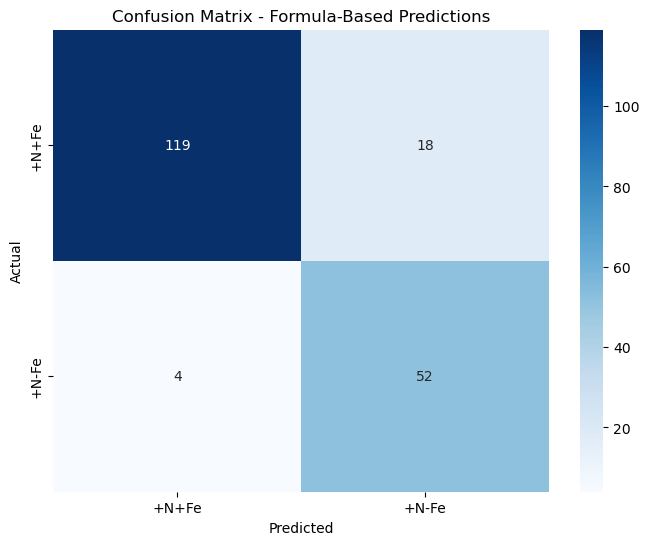


Standard Logistic Regression - Test Set Accuracy: 0.8860103626943006
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       137
           1       0.74      0.93      0.83        56

    accuracy                           0.89       193
   macro avg       0.86      0.90      0.87       193
weighted avg       0.90      0.89      0.89       193

Unique values in y_te: [0 1]
Unique values in y_pred: [0 1]


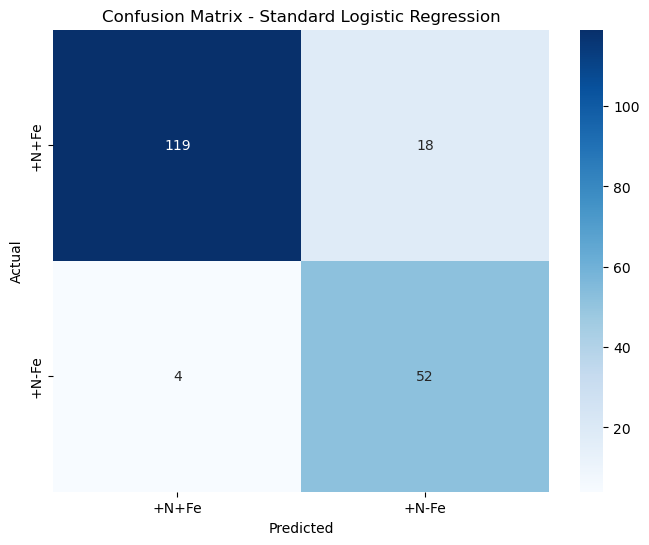

Linear Logistic Regression shap_values shape is (180, 9)


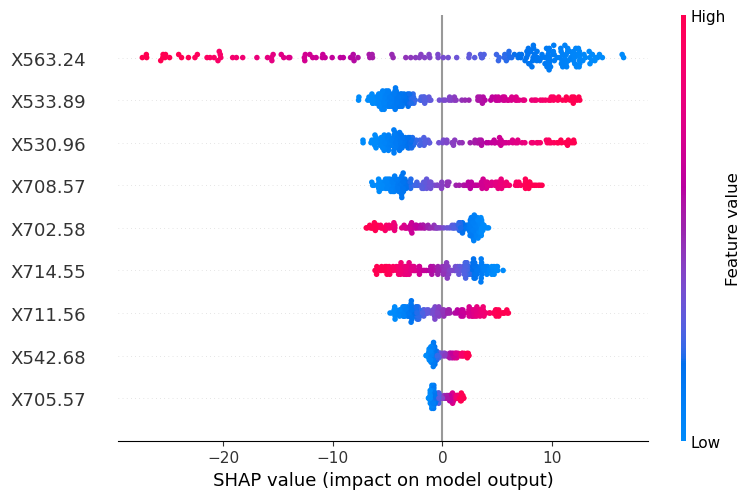

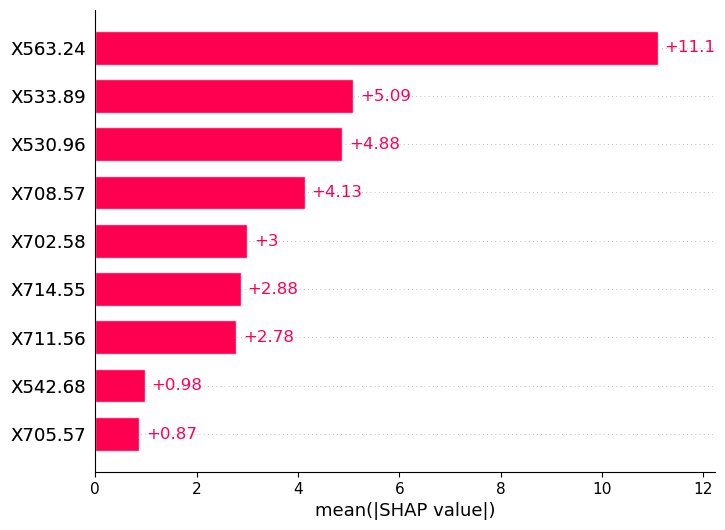

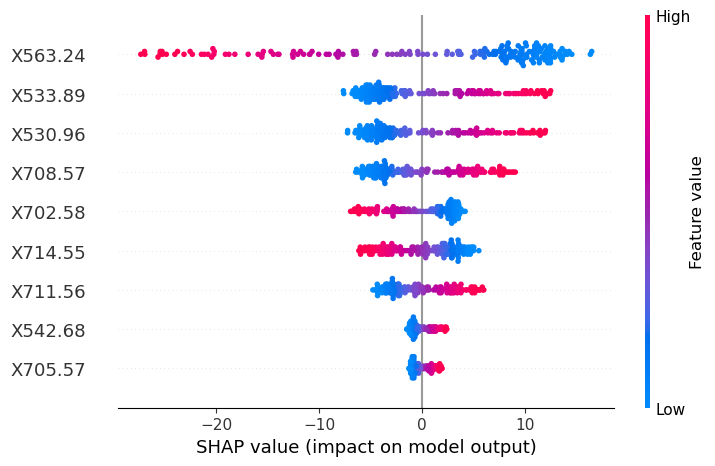

(180, 9)


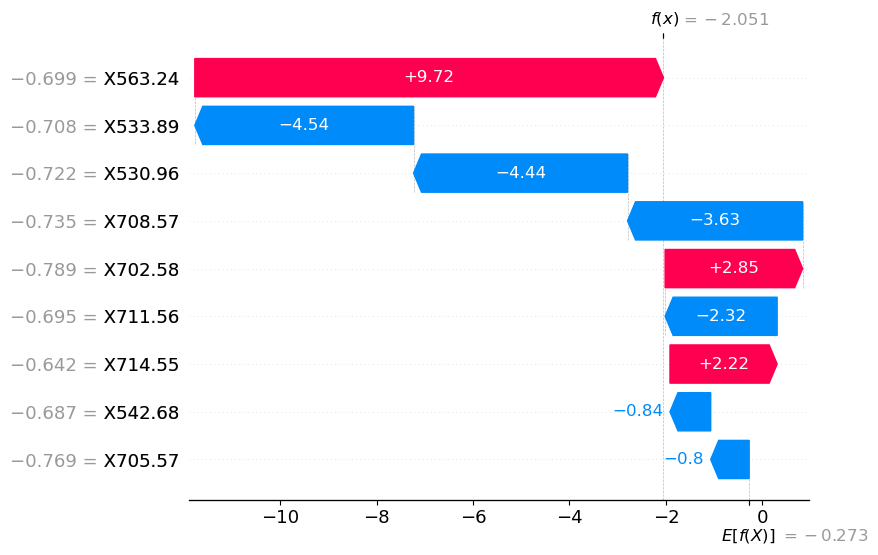

Model classes: [0 1]


In [48]:
### Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression ###
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'sag']
}
random_state= 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3,random_state=random_state), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# # Perform cross-validation
# cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
# print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
# print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Extract coefficients and intercept
coefficients = model.coef_[0]  # For binary classification; adjust for multiclass
intercept = model.intercept_[0]  # For binary classification; adjust for multiclass
# Print coefficients and intercept with feature names
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
# Save the coefficients and intercept to a .txt file without rounding
output_file = "feature_coefficients_exact.txt"
with open(output_file, "w") as f:
    f.write(f"Intercept: {intercept}\n")
    f.write("Coefficients:\n")
    for feature, coef in zip(feature_names, coefficients):
        f.write(f"{feature}: {coef}\n")
print(f"Exact coefficients and intercept saved to {output_file}")
# Make predictions on the test set
y_pred = model.predict(X_scaled_te)
# Calculate predictions using the logistic regression formula
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Compute the linear combination (z)
z = intercept + np.dot(X_scaled_te, coefficients)  # Use the test set features
# Apply sigmoid to get probabilities
probabilities = sigmoid(z)
# Convert probabilities to binary predictions with a threshold of 0.5
predictions_formula = (probabilities >= 0.5).astype(int)
# Validate against the genuine y_te
print("\nValidation of Logistic Regression Formula:")
print("Accuracy:", accuracy_score(y_te, predictions_formula))
print("Classification Report:\n", classification_report(y_te, predictions_formula))
# Plot confusion matrix as a heatmap for formula-based predictions
conf_matrix_formula = confusion_matrix(y_te, predictions_formula)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_formula, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Formula-Based Predictions")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# # Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_te, y_pred))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred))
# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# NEW: SHAP ANALYSIS, on train set to calculate inde formula
# Use LinearExplainer for logistic regression
explainer_llr = shap.LinearExplainer(model, X_train)
# Calculate SHAP values
shap_values_llr = explainer_llr.shap_values(X_train)
print("Linear Logistic Regression shap_values shape is", np.shape(shap_values_llr))
# Ensure base_values is an array
base_values_llr = np.full(shap_values_llr.shape[0], explainer_llr.expected_value)
# Create an Explanation object
shap_values_llr_explanation = shap.Explanation(
    shap_values_llr,
    base_values=base_values_llr,
    data=X_train,
    # feature_names = feature_names_reduced
    feature_names=feature_names
)
# Generate SHAP plots for the Train set
# Summary Plot
shap.summary_plot(shap_values_llr, X_train, feature_names=feature_names)
# shap.summary_plot(shap_values_llr, X_train, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_llr_explanation, max_display=10)
# Beeswarm Plot
shap.plots.beeswarm(shap_values_llr_explanation)
print(shap_values_llr_explanation.shape)
# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_llr_explanation[1])

print("Model classes:", model.classes_)

#### <font color=green> Random Forest </font>

Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 10}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.750000        0.127294   
1           0.772222        0.122852   
2           0.755556        0.147406   
3           0.750000        0.147510   
4           0.766667        0.133333   
..               ...             ...   
283         0.761111        0.164898   
284         0.800000        0.147406   
285         0.766667        0.158698   
286         0.766667        0.162542   
287         0.761111        0.164898   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': '

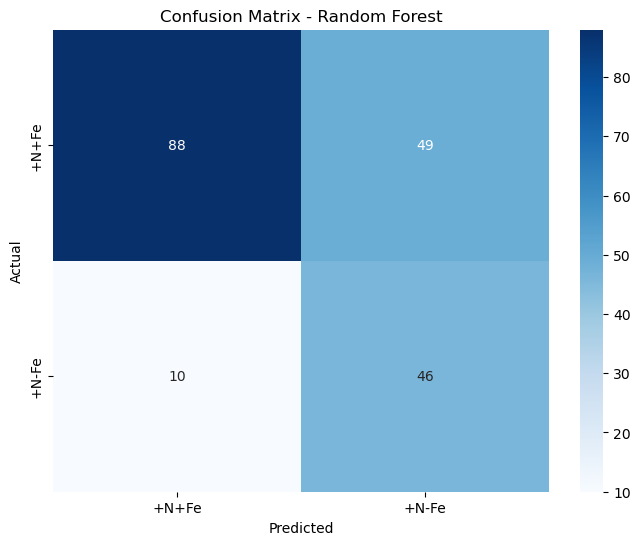

Random Forest shap_values shape is (180, 9, 2)
Selected SHAP values shape: (180, 9)


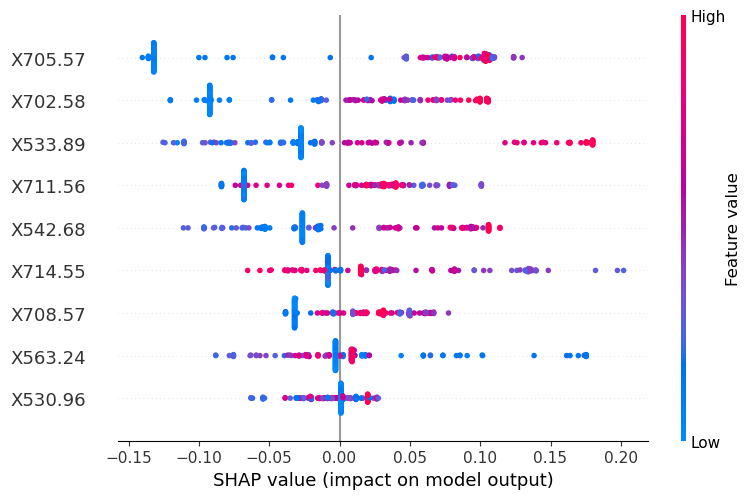

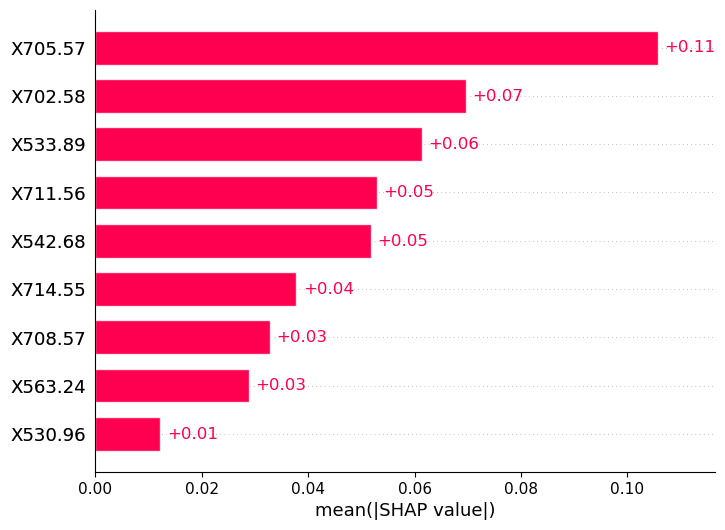

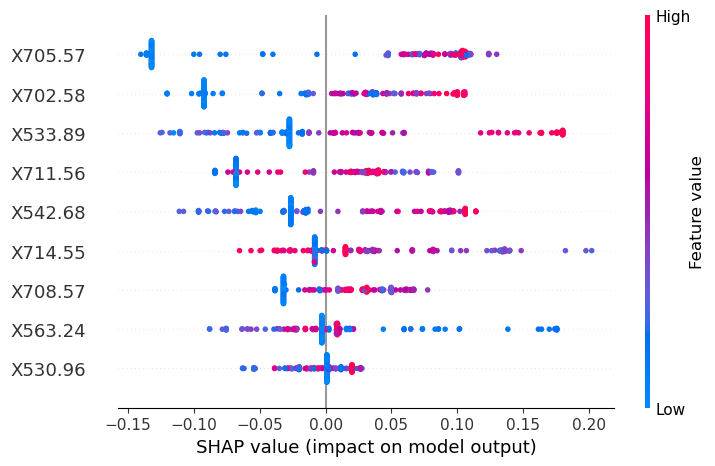

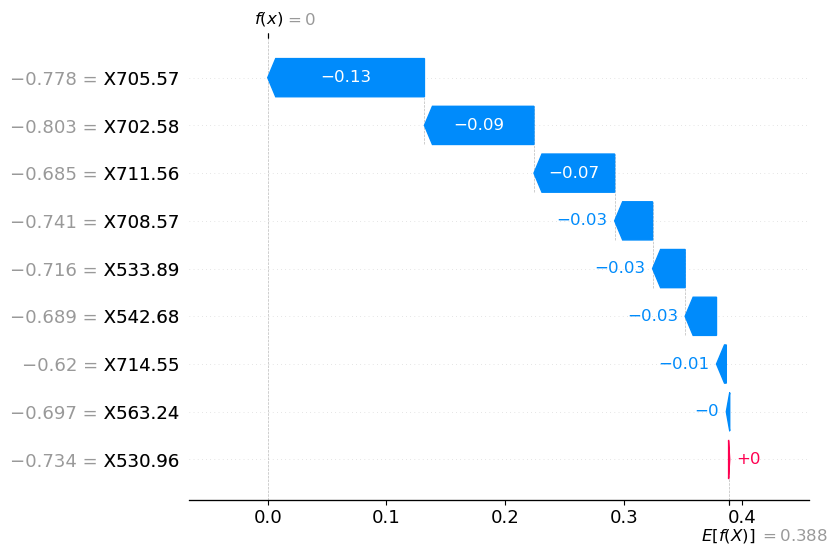

Model classes: [0 1]


In [49]:
### Random Forest Classifier ###
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_scaled_te)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_te, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred_rf))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))


# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SHAP Analysis, on train set
# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_train)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# Select the SHAP values for the positive class (class 1)
shap_values_rf_selected = shap_values_rf[:, :, 1]
# Print the shape of the resulting array
print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# Create an Explanation object
shap_values_rf_explanation = shap.Explanation(
    shap_values_rf_selected,
    base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
    data=X_train,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Generate SHAP plots for the Train set
# Summary Plot
shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names)
# shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_rf_explanation)

# Beeswarm Plot
shap.plots.beeswarm(shap_values_rf_explanation)

# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_rf_explanation[0])

print("Model classes:", rf_model.classes_)

In [60]:
print("Model classes:", model.classes_)


Model classes: [0 1]


### Uder the comission of the PhD student's order

#### Use the following cell as a <font color=red> "stand-alone Logistic Regression" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

 X_train size 108
 X_train size 36
Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: -0.11528419469869805
Coefficients:
X702.58: 2.0121660038179696
X705.57: 4.025703010845145
X714.55: -2.478092945494764
X708.57: 4.902654382007221
X711.56: 2.3716484718015844
X542.68: -3.854778572122978
X533.89: 4.138456220065122
X563.24: -15.477871473441985
X530.96: 6.579572059786899

Logistic Regression - Test Set Accuracy: 0.8611111111111112
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89        23
           1       0.83      0.77      0.80        13

    accuracy                           0.86        36
   macro avg       0.85      0.84      0.85        36
weighted avg       0.86      0.86      0.86        36



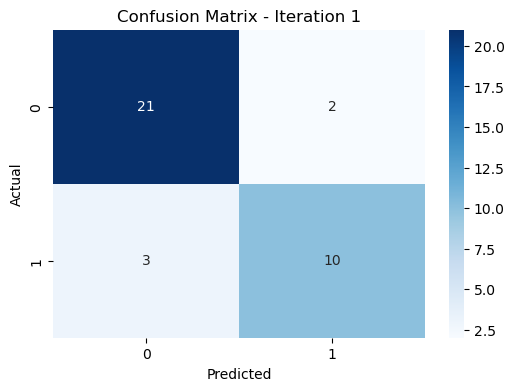

 X_train size 108
 X_train size 36
Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: 0.03549118005747792
Coefficients:
X702.58: 4.021708582047196
X705.57: 5.102584023809247
X714.55: -3.5774890290930674
X708.57: 5.237791276813555
X711.56: 2.4305336816053553
X542.68: -3.635673839760091
X533.89: 2.1339960982993533
X563.24: -12.64112173826284
X530.96: 3.504317181619884

Logistic Regression - Test Set Accuracy: 0.9166666666666666
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        22
           1       0.92      0.86      0.89        14

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



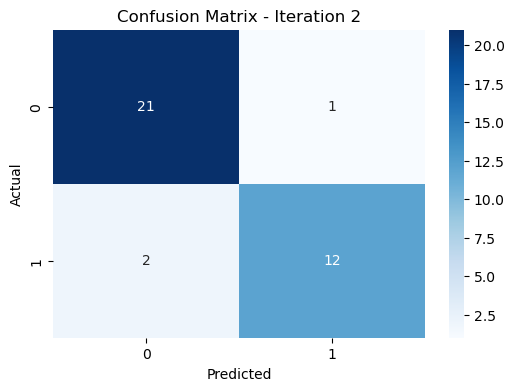

 X_train size 108
 X_train size 36
Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: -0.19377679617378438
Coefficients:
X702.58: 1.2501872390346167
X705.57: 4.747667453988794
X714.55: -3.919981483235019
X708.57: 6.0000407912329585
X711.56: 3.028021300333503
X542.68: -3.448191099448268
X533.89: 3.7878511471998166
X563.24: -15.018908601131855
X530.96: 5.798111248988164

Logistic Regression - Test Set Accuracy: 0.8055555555555556
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        21
           1       0.83      0.67      0.74        15

    accuracy                           0.81        36
   macro avg       0.81      0.79      0.79        36
weighted avg       0.81      0.81      0.80        36



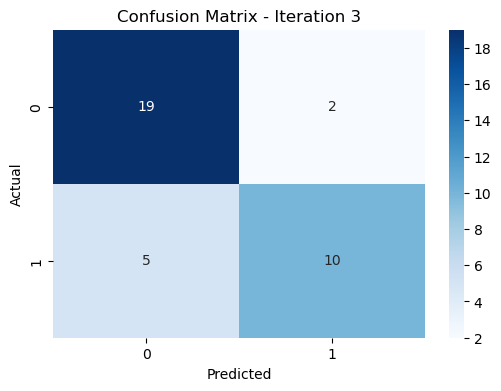

 X_train size 108
 X_train size 36
Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: 0.028599779204200038
Coefficients:
X702.58: 1.09984462857832
X705.57: 4.172466678253589
X714.55: -3.2641646823506836
X708.57: 5.300709144579176
X711.56: 2.7501407142418155
X542.68: -3.2139154231120752
X533.89: 4.3020545180953
X563.24: -15.444622184746553
X530.96: 6.5366083961851515

Logistic Regression - Test Set Accuracy: 0.8888888888888888
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        24
           1       0.75      1.00      0.86        12

    accuracy                           0.89        36
   macro avg       0.88      0.92      0.88        36
weighted avg       0.92      0.89      0.89        36



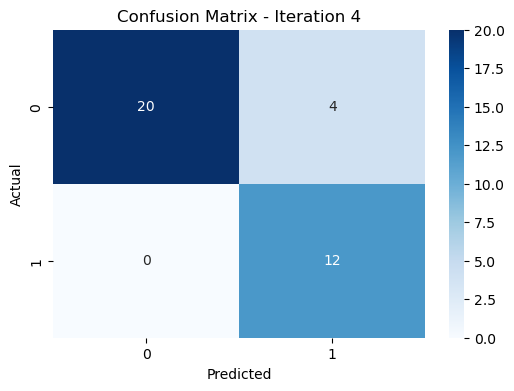


Average Accuracy Across 4 Iterations: 0.8680555555555555
All runs' coefficients and averaged results saved to feature_coefficients_all_runs_and_average.txt


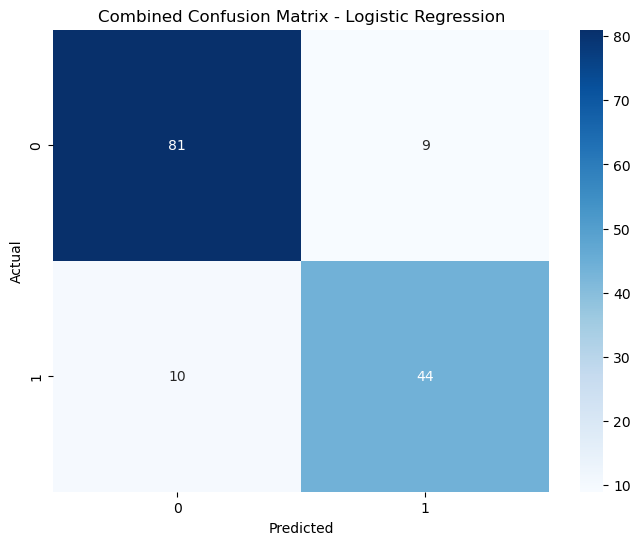


Overall Precision: 0.8680555555555556
Overall Recall: 0.8680555555555556
Overall F1-score: 0.8680555555555556


In [82]:
# Function to train and evaluate a model, and compute SHAP values
def train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names):
    # Define the parameter grid for Logistic Regression
    param_grid_lr = {
        'C': [0.01, 0.1, 1, 10, 30],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
    }

    # Initialize the Logistic Regression model
    lr_model = LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state)

    # Perform GridSearchCV with cross-validation
    grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=5, scoring='accuracy')
    grid_search_lr.fit(X_train, y_train)
    best_params_lr = grid_search_lr.best_params_
    print("Best parameters for Logistic Regression:", best_params_lr)

    # Train the best model on the entire training set
    best_lr_model = LogisticRegression(**best_params_lr, max_iter=1000, tol=1e-3, random_state=random_state)
    best_lr_model.fit(X_train, y_train)

    # Extract coefficients and intercept
    coefficients = best_lr_model.coef_[0]  # For binary classification; adjust for multiclass
    intercept = best_lr_model.intercept_[0]  # For binary classification; adjust for multiclass

    # Print coefficients and intercept with feature names
    print("Intercept:", intercept)
    print("Coefficients:")
    for feature, coef in zip(feature_names, coefficients):
        print(f"{feature}: {coef}")

    # Make predictions on the test set
    y_pred = best_lr_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print("\nLogistic Regression - Test Set Accuracy:", accuracy)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Calculate SHAP values
    explainer = shap.Explainer(best_lr_model, X_train)
    shap_values = explainer(X_test)
    return accuracy, conf_matrix, y_test, y_pred, shap_values, feature_names, intercept, coefficients


# Initialize random state
random_state = 42

# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}

# Shuffle the data for each plant once before starting the for loops
for plant in plant_groups_scaled.keys():
    X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
    plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# Lists to store accuracies, confusion matrices, predictions, SHAP values, intercepts, and coefficients from each iteration
accuracies = []
conf_matrices = []
all_y_true = []
all_y_pred = []
shap_values_list = []
all_intercepts = []
all_coefficients = []

# Number of splits
n_splits = 4

# Iterate to split the dataset
for i in range(n_splits):
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Iterate over each plant species
    for plant in plant_groups_scaled.keys():
        X = plant_groups_scaled[plant][0]
        y = plant_groups_scaled[plant][1]

        # Define the indices for the current split
        test_size = len(X) // n_splits
        test_indices = range(i * test_size, (i + 1) * test_size)
        train_indices = list(set(range(len(X))) - set(test_indices))

        # Split the data for the current iteration
        X_train_plant = X[train_indices]
        y_train_plant = y[train_indices]
        X_test_plant = X[test_indices]
        y_test_plant = y[test_indices]

        # Append to the respective lists
        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

    # Concatenate the lists to form the final train and test sets
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    print(" X_train size", len(X_train))
    print(" X_train size", len(X_test))
    # Shuffle the concatenated train and test sets to remove any order-based bias
    X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    # Train and evaluate the model, and get SHAP values
    accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names, intercept, coefficients = train_evaluate_shap(
        X_train, y_train, X_test, y_test, feature_names
    )

    # Append the current results to the lists
    accuracies.append(accuracy)
    conf_matrices.append(conf_matrix)
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    shap_values_list.append(shap_values)
    all_intercepts.append(intercept)
    all_coefficients.append(coefficients)

    # Plot the confusion matrix for each iteration
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - Iteration {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)
print("\nAverage Accuracy Across 4 Iterations:", average_accuracy)

# Combine confusion matrices by summing them up
combined_conf_matrix = np.sum(conf_matrices, axis=0)

# Calculate the averaged intercept and coefficients
averaged_intercept = np.mean(all_intercepts)
averaged_coefficients = np.mean(all_coefficients, axis=0)

# Save the results of each run and their average to a .txt file
output_file = "feature_coefficients_all_runs_and_average.txt"
with open(output_file, "w") as f:
    # Header
    f.write("Intercepts and Coefficients for Each Run:\n")
    f.write("======================================\n\n")

    # Write the results for each run
    for i, (intercept, coef_list) in enumerate(zip(all_intercepts, all_coefficients)):
        f.write(f"Run {i + 1}:\n")
        f.write(f"Intercept: {intercept}\n")
        f.write("Coefficients:\n")
        for feature, coef in zip(feature_names, coef_list):
            f.write(f"{feature}: {coef}\n")
        f.write("\n")  # Add a newline between runs

    # Write the averaged intercept and coefficients
    f.write("\nAveraged Intercept and Coefficients:\n")
    f.write("======================================\n")
    f.write(f"Averaged Intercept: {averaged_intercept}\n")
    f.write("Averaged Coefficients:\n")
    for feature, coef in zip(feature_names, averaged_coefficients):
        f.write(f"{feature}: {coef}\n")

print(f"All runs' coefficients and averaged results saved to {output_file}")

# Plot the combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Combined Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate precision, recall, and F1-score using the aggregated results
precision = precision_score(all_y_true, all_y_pred, average='micro')
recall = recall_score(all_y_true, all_y_pred, average='micro')
f1 = f1_score(all_y_true, all_y_pred, average='micro')

print(f"\nOverall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall F1-score: {f1}")




#### Use the following cell as a <font color=red> "stand-alone RandomForest" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}

Random Forest - Test Set Accuracy: 0.7777777777777778
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        23
           1       0.73      0.62      0.67        13

    accuracy                           0.78        36
   macro avg       0.76      0.74      0.75        36
weighted avg       0.77      0.78      0.77        36

shap_values_rf's shape (36, 9, 2)


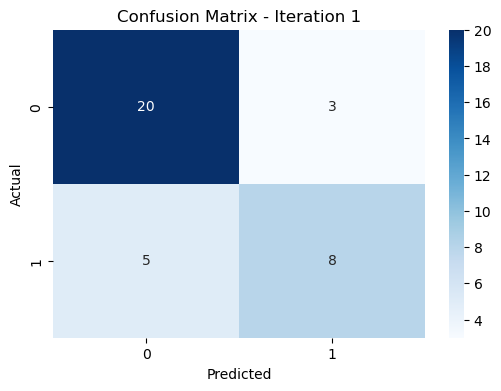

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Random Forest - Test Set Accuracy: 0.9444444444444444
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        22
           1       0.93      0.93      0.93        14

    accuracy                           0.94        36
   macro avg       0.94      0.94      0.94        36
weighted avg       0.94      0.94      0.94        36

shap_values_rf's shape (36, 9, 2)


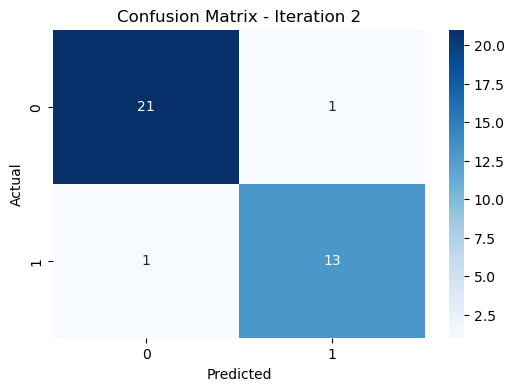

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)
Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Random Forest - Test Set Accuracy: 0.7777777777777778
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        21
           1       0.71      0.80      0.75        15

    accuracy                           0.78        36
   macro avg       0.77      0.78      0.78        36
weighted avg       0.79      0.78      0.78        36

shap_values_rf's shape (36, 9, 2)


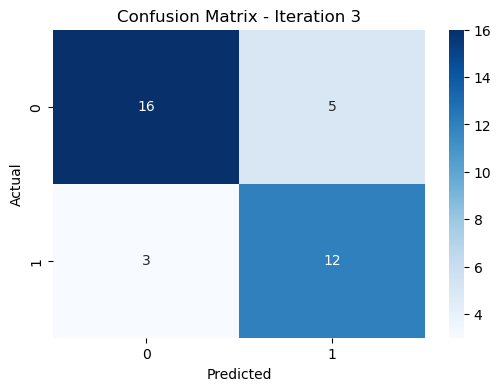

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 10}

Random Forest - Test Set Accuracy: 0.7777777777777778
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81        24
           1       0.61      0.92      0.73        12

    accuracy                           0.78        36
   macro avg       0.78      0.81      0.77        36
weighted avg       0.83      0.78      0.78        36

shap_values_rf's shape (36, 9, 2)


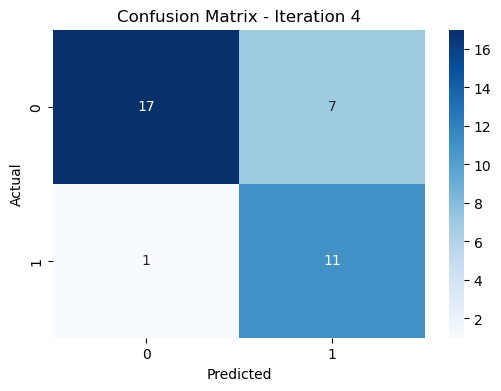


Average Accuracy Across 4 Iterations: 0.8194444444444444


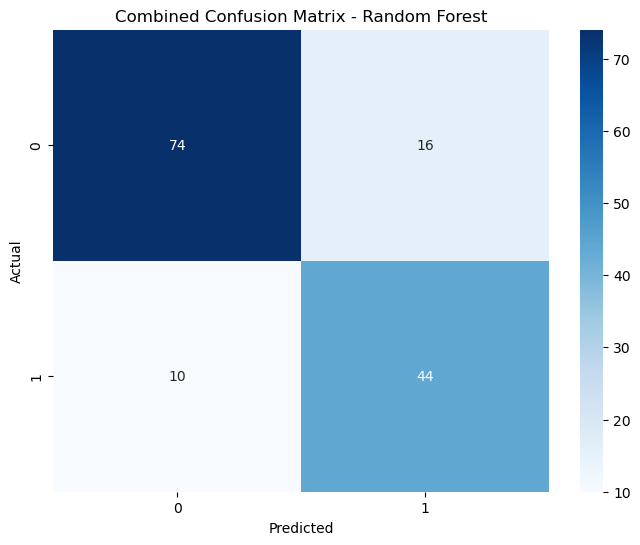


Overall Precision: 0.8194444444444444
Overall Recall: 0.8194444444444444
Overall F1-score: 0.8194444444444444


In [75]:
# Function to train and evaluate a model, and compute SHAP values
def train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names):
    # Define the parameter grid for Random Forest
    param_grid_rf = {
        'n_estimators': [10, 50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    random_state = 42

    # Perform GridSearchCV with cross-validation
    grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
    grid_search_rf.fit(X_train, y_train)
    best_params_rf = grid_search_rf.best_params_
    print("Best parameters for Random Forest:", best_params_rf)

    # Initialize the best Random Forest model
    best_rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)
    best_rf_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_rf = best_rf_model.predict(X_test)

    # Evaluate the model
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    print("\nRandom Forest - Test Set Accuracy:", accuracy_rf)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred_rf))

    # Confusion Matrix
    conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

    # Calculate SHAP values using TreeExplainer
    explainer_rf = shap.TreeExplainer(best_rf_model)
    shap_values_rf = explainer_rf.shap_values(X_test)
    print("shap_values_rf's shape", shap_values_rf.shape)
    return accuracy_rf, conf_matrix_rf, y_test, y_pred_rf, shap_values_rf, explainer_rf, feature_names

# Initialize random state
random_state = 42

# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}

# 😶😶😶😶😶😶😶😶😶😶😶😶
# Shuffle the data for each plant once before starting the for loops
for plant in plant_groups_scaled.keys():
    X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
    plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
accuracies_rf = []
conf_matrices_rf = []
all_y_true_rf = []
all_y_pred_rf = []
shap_values_list_rf = []
explainer_rf_list = []

# Number of splits
n_splits = 4

# Iterate to split the dataset
for i in range(n_splits):
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Iterate over each plant species
    for plant in plant_groups_scaled.keys():
        X = plant_groups_scaled[plant][0]
        y = plant_groups_scaled[plant][1]
        
        # Define the indices for the current split
        test_size = len(X) // n_splits
        test_indices = range(i * test_size, (i + 1) * test_size)
        train_indices = list(set(range(len(X))) - set(test_indices))
        
        # Split the data for the current iteration
        X_train_plant = X[train_indices]
        y_train_plant = y[train_indices]
        X_test_plant = X[test_indices]
        y_test_plant = y[test_indices]
        
        # Append to the respective lists
        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

    # Concatenate the lists to form the final train and test sets
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    # 😶😶😶😶😶😶😶😶😶😶😶😶
    # Shuffle the concatenated train and test sets to remove any order-based bias
    X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    
    # Confirm the shape of the train and test sets
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Train and evaluate the model, and get SHAP values
    accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names)
    # accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names_reduced)

    
    accuracies_rf.append(accuracy_rf)
    conf_matrices_rf.append(conf_matrix_rf)
    all_y_true_rf.extend(y_true_rf)
    all_y_pred_rf.extend(y_pred_rf)
    shap_values_list_rf.append(shap_values_rf)
    explainer_rf_list.append(explainer_rf)

    # Plot the confusion matrix for each iteration
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - Iteration {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Calculate the average accuracy
average_accuracy_rf = np.mean(accuracies_rf)
print("\nAverage Accuracy Across 4 Iterations:", average_accuracy_rf)

# Combine confusion matrices by summing them up
# Combine confusion matrices by summing them up
combined_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)

# Plot the combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Combined Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate precision, recall, and F1-score using the aggregated results
precision_rf = precision_score(all_y_true_rf, all_y_pred_rf, average='micro')
recall_rf = recall_score(all_y_true_rf, all_y_pred_rf, average='micro')
f1_rf = f1_score(all_y_true_rf, all_y_pred_rf, average='micro')

print(f"\nOverall Precision: {precision_rf}")
print(f"Overall Recall: {recall_rf}")
print(f"Overall F1-score: {f1_rf}")
